# Monotone Quantile GRU — stripped-down test

A self-contained sanity test of the **monotone quantile construction** for the
direct multi-horizon prosumption forecaster.

**Scope (deliberately stripped):** history-only (a single input tensor), no
per-horizon exogenous features, no warm-start, no copula. This tests only that
the monotone head trains, produces strictly-ordered quantiles, calibrates on
synthetic data, and lets gradients flow. The full pipeline adds the per-horizon
exogenous path, more quantile levels, and regularisation.

> Requires PyTorch. Run in an environment with `torch` installed
> (not executed when this notebook was authored).

## 1. Imports

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

## 2. The model

Monotone by construction: the head emits one **base** quantile plus
(`num_quantiles - 1`) **increments**; softplus forces the increments positive
and a cumulative sum makes the quantiles strictly increasing — for any network
output, with nothing to learn. History-only: `forward` takes a single tensor
`x` of shape `(batch, seq_len, input_size)`.

In [ ]:
class MonotonicQuantileGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_quantiles=19, horizon=24):
        super().__init__()

        ## define forecaster architecture
        self.num_quantiles = num_quantiles
        self.horizon = horizon
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, horizon * num_quantiles)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]                                   # final hidden state
        raw = self.fc(out).reshape(-1, self.horizon, self.num_quantiles)
        base = raw[..., 0:1]                                  # lowest quantile
        inc = F.softplus(raw[..., 1:]) + 1e-4                 # strictly positive
        quantiles = torch.cat(
            [base, base + torch.cumsum(inc, dim=-1)], dim=-1) # (B, H, Q), increasing in Q
        return quantiles

## 3. Quantile levels and pinball loss

The levels must match `num_quantiles` and be increasing; the base quantile
corresponds to the lowest level. Nine levels here to match the stripped test —
for the copula downstream you would typically use more (e.g. 0.05..0.95).

In [ ]:
QUANTILE_LEVELS = torch.tensor(np.arange(0.05, 1.00, 0.05))
assert len(QUANTILE_LEVELS) == 19  # keep in sync with num_quantiles below

def pinball_loss(y_true, y_pred, levels):
    # y_true: (B, H)   y_pred: (B, H, Q)   levels: (Q,)
    e = y_true.unsqueeze(-1) - y_pred
    q = levels.view(1, 1, -1)
    return torch.maximum(q * e, (q - 1) * e).mean()

## 4. Synthetic prosumption data

A diurnal + weekly + midday-solar-dip signal with noise (can go negative, like
net load). Windowed into (history → next 24h) pairs at daily origins, then
standardised on the training slice only.

In [12]:
H = 24                       # forecast horizon (hours)
SEQ = 48                     # history length fed to the GRU
N_HOURS = 24 * 800           # ~800 days
t = np.arange(N_HOURS)
hour = t % 24
day = t // 24
diurnal = 1.5 * np.sin(2 * np.pi * (hour - 18) / 24)              # evening-ish peak
solar   = 2.5 * np.clip(np.sin(2 * np.pi * (hour - 6) / 24), 0, None)  # midday PV dip
weekly  = 0.4 * np.sin(2 * np.pi * day / 7)
series  = 3.0 + diurnal - solar + weekly + 0.4 * np.random.randn(N_HOURS)

# window into (history -> next 24h) pairs, one origin per day
origins = np.arange(SEQ, N_HOURS - H, 24)
X = np.stack([series[o - SEQ:o] for o in origins])[..., None]     # (N, SEQ, 1)
Y = np.stack([series[o:o + H]   for o in origins])                # (N, H)

# chronological split; standardise on TRAIN only
n_train = int(0.8 * len(X))
mu, sd = series[:origins[n_train]].mean(), series[:origins[n_train]].std()
Xn, Yn = (X - mu) / sd, (Y - mu) / sd

to_t = lambda a: torch.tensor(a, dtype=torch.float32)
Xtr, Ytr = to_t(Xn[:n_train]), to_t(Yn[:n_train])
Xva, Yva = to_t(Xn[n_train:]), to_t(Yn[n_train:])
print("train:", tuple(Xtr.shape), tuple(Ytr.shape), "| val:", tuple(Xva.shape), tuple(Yva.shape))

train: (637, 48, 1) (637, 24) | val: (160, 48, 1) (160, 24)


## 5. Train

In [13]:
model = MonotonicQuantileGRU(input_size=1, hidden_size=32,
                             num_quantiles=len(QUANTILE_LEVELS), horizon=H)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(150):
    model.train()
    perm = torch.randperm(len(Xtr))
    for i in range(0, len(Xtr), 64):
        b = perm[i:i + 64]
        opt.zero_grad()
        loss = pinball_loss(Ytr[b], model(Xtr[b]), QUANTILE_LEVELS)
        loss.backward()
        opt.step()
    if (epoch + 1) % 30 == 0:
        model.eval()
        with torch.no_grad():
            vl = pinball_loss(Yva, model(Xva), QUANTILE_LEVELS).item()
        print(f"epoch {epoch + 1:3d} | val pinball {vl:.4f}")

epoch  30 | val pinball 0.0763
epoch  60 | val pinball 0.0745
epoch  90 | val pinball 0.0743
epoch 120 | val pinball 0.0743
epoch 150 | val pinball 0.0740


## 6. Verify monotonicity

The construction guarantees strictly-increasing quantiles for *any* output, so
this should always pass — it's a regression guard, not a hope.

In [14]:
model.eval()
with torch.no_grad():
    q_va = model(Xva)                       # (N, H, Q), standardised space
diffs = torch.diff(q_va, dim=-1)
print("monotone (all increments > 0):", bool((diffs > 0).all()))
print("min increment:", float(diffs.min()))

# monotonicity is preserved by the (positive-scale) inverse-standardisation:
assert sd > 0
q_phys = q_va.numpy() * sd + mu
assert np.all(np.diff(q_phys, axis=-1) > 0), "physical-unit quantiles must stay ordered"
print("monotone after inverse-standardise: True")

monotone (all increments > 0): True
min increment: 0.05543839931488037
monotone after inverse-standardise: True


## 7. Verify calibration

Empirical coverage at each level = fraction of realised values at or below the
predicted quantile. On well-fit data these should land near the nominal levels
(0.1, 0.2, ... 0.9).

In [15]:
with torch.no_grad():
    cover = [(Yva.unsqueeze(-1) <= q_va[..., k:k + 1]).float().mean().item()
             for k in range(len(QUANTILE_LEVELS))]
for a, c in zip(QUANTILE_LEVELS.tolist(), cover):
    print(f"level {a:.1f}:  empirical coverage {c:.3f}")

max_dev = max(abs(a - c) for a, c in zip(QUANTILE_LEVELS.tolist(), cover))
print(f"\nmax |coverage - nominal| = {max_dev:.3f}  (small = well calibrated)")

level 0.1:  empirical coverage 0.083
level 0.2:  empirical coverage 0.197
level 0.3:  empirical coverage 0.297
level 0.4:  empirical coverage 0.396
level 0.5:  empirical coverage 0.502
level 0.6:  empirical coverage 0.608
level 0.7:  empirical coverage 0.711
level 0.8:  empirical coverage 0.813
level 0.9:  empirical coverage 0.912

max |coverage - nominal| = 0.017  (small = well calibrated)


## 8. Plot one forecast (physical units)

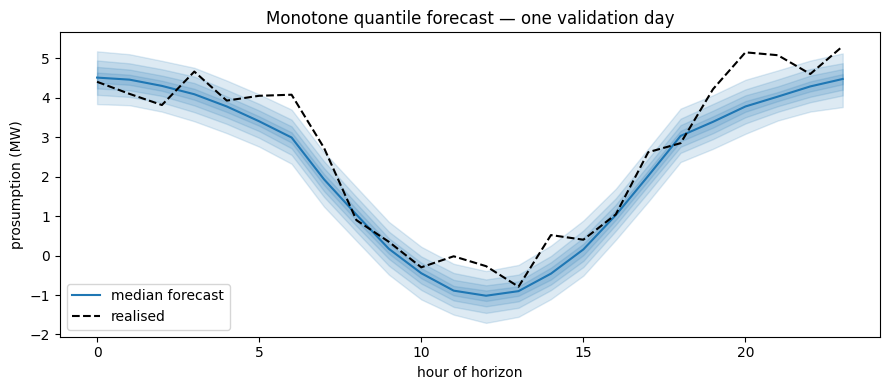

In [16]:
i = 0
qp = q_va[i].numpy() * sd + mu          # (H, Q) physical units
yp = Yva[i].numpy() * sd + mu
hrs = np.arange(H)
mid = len(QUANTILE_LEVELS) // 2

plt.figure(figsize=(9, 4))
for k in range(mid):                    # nested prediction bands
    plt.fill_between(hrs, qp[:, k], qp[:, -1 - k], alpha=0.15, color="C0")
plt.plot(hrs, qp[:, mid], color="C0", label="median forecast")
plt.plot(hrs, yp, "k--", label="realised")
plt.xlabel("hour of horizon"); plt.ylabel("prosumption (MW)")
plt.title("Monotone quantile forecast — one validation day")
plt.legend(); plt.tight_layout(); plt.show()

## What this does and does not test

**Tests:** the monotone construction (strictly-ordered quantiles by
construction), that the model trains under pinball loss, that gradients flow,
that quantiles are calibrated on synthetic data, and that monotonicity survives
the inverse-standardisation.

**Does *not* test (out of scope for this stripped version):**
per-horizon exogenous features (calendar / weather forecast) — the full model
takes `x_hist` **and** `x_exo`; copula-fidelity quantile resolution (use ~19
levels, e.g. 0.05..0.95, downstream); warm-starting; regularisation tuning
(add dropout + early stopping for the real run); and out-of-sample calibration
on real held-out data (here the split is synthetic).